<a href="https://colab.research.google.com/github/ard0p8v/KSU2_HierarchicalWeatherForecasting/blob/main/weather_hierarchy_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zápočtový úkol 1 - Predikce z hierarchických dat
**Předmět:** Strojové učení II (KSU2)  
**Autor:** Bc. Pavel Ardolf   
**GitHub Repozitář:** https://github.com/ard0p8v/KSU2_HierarchicalWeatherForecasting

---

## 1. Cíl projektu
Cílem práce je implementovat a porovnat dvě základní metody předpovídání na hierarchicky uspořádaných datech (Bottom-Up, Top-Down). Projekt demonstruje schopnost pracovat s daty, která jsou vzájemně provázána v logické struktuře (stromu).

## 2. Popis hierarchie a dat
Pro projekt byla zvolena meteorologická data (teplota), která tvoří tříúrovňovou hierarchii:
* **Úroveň 0 (Top):** Kontinent (Evropa) – agregovaný průměr ze všech sledovaných států.
* **Úroveň 1 (Middle):** Státy (CZ, AT, DE, PL, SK) – průměr z vybraných měst v dané zemi.
* **Úroveň 2 (Bottom):** Města (např. Praha, Brno, Vídeň, Berlín atd.) – primární zdroj dat.

**Datový zdroj:** Data byla stažena pomocí Open-Meteo API za období 2019–2023. Celkem dataset obsahuje denní záznamy pro více než 20 evropských měst.

## 3. Metodika
V notebooku jsou realizovány následující kroky:
1. **Příprava dat:** Načtení CSV souborů a kontrola koherence hierarchie.
2. **Exploratory Data Analysis (EDA):** Vizualizace historických trendů a sezónnosti.
3. **Modelování:**
   - **Bottom-Up:** Trénování modelu (Prophet) pro každé město a následná agregace výsledků nahoru.
   - **Top-Down:** Předpověď pro kontinent a následná distribuce (disagregace) směrem dolů pomocí historických odchylek (offsetů).
4. **Evaluace:** Porovnání přesnosti metod pomocí metrik MAE, RMSE a R².

In [6]:
"""
Obsah skriptu:
- Stahování dat z Open-Meteo API
- Agregace měst do států a států do kontinentu
- Kontrola integrity hierarchie
"""
!pip install openmeteo-requests requests-cache retry-requests
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import numpy as np
import os

# Init konfigurace
START_DATE = "2019-01-01"
END_DATE   = "2023-12-31"
OUTPUT_DIR = "data"

# Hierarchická struktura - kontinent → stát → město → lat, lon
CITIES = {
    "CZ": {
        "Praha":          (50.0755, 14.4378),
        "Brno":           (49.1951, 16.6068),
        "Ostrava":        (49.8209, 18.2625),
        "Hradec Králové": (50.2092, 15.8328),
        "Plzeň":          (49.7384, 13.3736),
        "Liberec":        (50.7663, 15.0543),
    },
    "DE": {
        "Berlín":   (52.5200, 13.4050),
        "Mnichov":  (48.1351, 11.5820),
        "Hamburg":  (53.5753, 10.0153),
        "Frankfurt":(50.1109, 8.6821),
    },
    "AT": {
        "Vídeň":    (48.2082, 16.3738),
        "Salzburg": (47.8095, 13.0550),
        "Innsbruck":(47.2692, 11.4041),
    },
    "PL": {
        "Varšava": (52.2297, 21.0122),
        "Krakov":  (50.0647, 19.9450),
        "Wrocław": (51.1079, 17.0385),
    },
    "SK": {
        "Bratislava": (48.1486, 17.1077),
        "Košice":     (48.7164, 21.2611),
    },
}

# Stažení dat
def download_all(cities: dict, start: str, end: str) -> pd.DataFrame:
    cache_session = requests_cache.CachedSession(".om_cache", expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.3)
    client = openmeteo_requests.Client(session=retry_session)

    records = []
    total = sum(len(v) for v in cities.values())
    done = 0

    import time

    for country, city_dict in cities.items():
        for city, (lat, lon) in city_dict.items():
            done += 1
            print(f"  [{done}/{total}] {city} ({country})...", end=" ", flush=True)

            params = {
                "latitude":   lat,
                "longitude":  lon,
                "daily":      [
                    "temperature_2m_max",
                    "temperature_2m_min",
                    "precipitation_sum",
                ],
                "start_date": start,
                "end_date":   end,
                "timezone":   "Europe/Prague",
            }

            try:
                resp = client.weather_api(
                    "https://archive-api.open-meteo.com/v1/archive",
                    params=params
                )
            except Exception as e:
                print(f"CHYBA: {e} — čekám 60s a zkouším znovu...")
                time.sleep(60)
                resp = client.weather_api(
                    "https://archive-api.open-meteo.com/v1/archive",
                    params=params
                )

            r = resp[0]
            daily = r.Daily()

            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            )

            df = pd.DataFrame({
                "date":        dates,
                "continent":   "Evropa",
                "country":     country,
                "city":        city,
                "temp_max":    daily.Variables(0).ValuesAsNumpy(),
                "temp_min":    daily.Variables(1).ValuesAsNumpy(),
                "precip_sum":  daily.Variables(2).ValuesAsNumpy(),
            })
            df["temp_mean"] = (df["temp_max"] + df["temp_min"]) / 2.0
            records.append(df)
            print("OK")

            time.sleep(2)

    df_all = pd.concat(records, ignore_index=True)
    df_all["date"] = df_all["date"].dt.tz_localize(None)
    return df_all


# Agregace na vyšší úrovně hierarchie
def build_hierarchy(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Vrátí slovník DataFramů pro každou úroveň hierarchie.

    Úroveň 0 – Evropa (průměr přes všechna města)
    Úroveň 1 – Stát   (průměr přes města v dané zemi)
    Úroveň 2 – Město  (raw data)
    """
    grp = ["date"]

    level_city = df.copy()

    level_country = (
        df.groupby(["date", "continent", "country"], as_index=False)
        .agg(
            temp_max=("temp_max", "mean"),
            temp_min=("temp_min", "mean"),
            temp_mean=("temp_mean", "mean"),
            precip_sum=("precip_sum", "mean"),
        )
    )

    level_continent = (
        level_country.groupby(["date", "continent"], as_index=False)
        .agg(
            temp_max=("temp_max", "mean"),
            temp_min=("temp_min", "mean"),
            temp_mean=("temp_mean", "mean"),
            precip_sum=("precip_sum", "mean"),
        )
    )

    return {
        "city":      level_city,
        "country":   level_country,
        "continent": level_continent,
    }


# Rychlá EDA
def print_eda(hierarchy: dict):
    print("\n" + "="*60)
    print("PŘEHLED DATASETU")
    print("="*60)

    for level, df in hierarchy.items():
        print(f"\n── Úroveň: {level.upper()} ──")
        print(f"   Řádků:       {len(df):,}")
        print(f"   Sloupců:     {list(df.columns)}")
        if "city" in df.columns:
            print(f"   Měst:        {df['city'].nunique()}")
        if "country" in df.columns:
            print(f"   Zemí:        {df['country'].nunique()}")
        print(f"   Chybějící:   {df.isnull().sum().to_dict()}")
        print(f"   Temp_mean:   {df['temp_mean'].min():.1f} – {df['temp_mean'].max():.1f} °C")
        print(f"   Precip_sum:  {df['precip_sum'].min():.1f} – {df['precip_sum'].max():.1f} mm")

    print("\n── KOHERENCE HIERARCHIE ──")
    city_df    = hierarchy["city"]
    country_df = hierarchy["country"]

    check = (
        city_df.groupby(["date", "country"])["temp_mean"].mean()
        .reset_index()
        .merge(country_df[["date", "country", "temp_mean"]], on=["date", "country"])
    )
    max_diff = (check["temp_mean_x"] - check["temp_mean_y"]).abs().max()
    print(f"   Max. odchylka město→stát: {max_diff:.6f} °C (ideálně < 0.001)")


# Uložení
def save(hierarchy: dict, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)
    for level, df in hierarchy.items():
        path = os.path.join(output_dir, f"weather_{level}.csv")
        df.to_csv(path, index=False)
        print(f"   Uloženo: {path}  ({len(df):,} řádků)")

if __name__ == "__main__":
    print("=" * 60)
    print("STAHOVÁNÍ DAT Z OPEN-METEO")
    print(f"Období: {START_DATE} → {END_DATE}")
    print(f"Měst celkem: {sum(len(v) for v in CITIES.values())}")
    print("=" * 60 + "\n")

    # 1. Stažení
    df_raw = download_all(CITIES, START_DATE, END_DATE)
    print(f"\nStaženo celkem: {len(df_raw):,} řádků\n")

    # 2. Sestavení hierarchie
    print("Sestavuji hierarchii...")
    hierarchy = build_hierarchy(df_raw)

    # 3. EDA
    print_eda(hierarchy)

    # 4. Uložení
    print("\nUkládám soubory...")
    save(hierarchy, OUTPUT_DIR)

    print("\nHotovo! Soubory jsou v adresáři ./data/")
    print("  weather_city.csv      — úroveň město (nejnižší)")
    print("  weather_country.csv   — úroveň stát")
    print("  weather_continent.csv — úroveň kontinent (nejvyšší)")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.7/208.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
STAHOVÁNÍ DAT Z OPEN-METEO
Období: 2019-01-01 → 2023-12-31
Měst celkem: 18

  [1/18] Praha (CZ)... OK
  [2/18] Brno (CZ)... OK
  [3/18] Ostrava (CZ)... OK
  [4/18] Hradec Králové (CZ)... OK
  [5/18] Plzeň (CZ)... OK
  [6/18] Liberec (CZ)... OK
  [7/18] Berlín (DE

In [2]:
!pip install prophet

import os
import pandas as pd

# Vytvoření složky data, pokud neexistuje
os.makedirs('data', exist_ok=True)

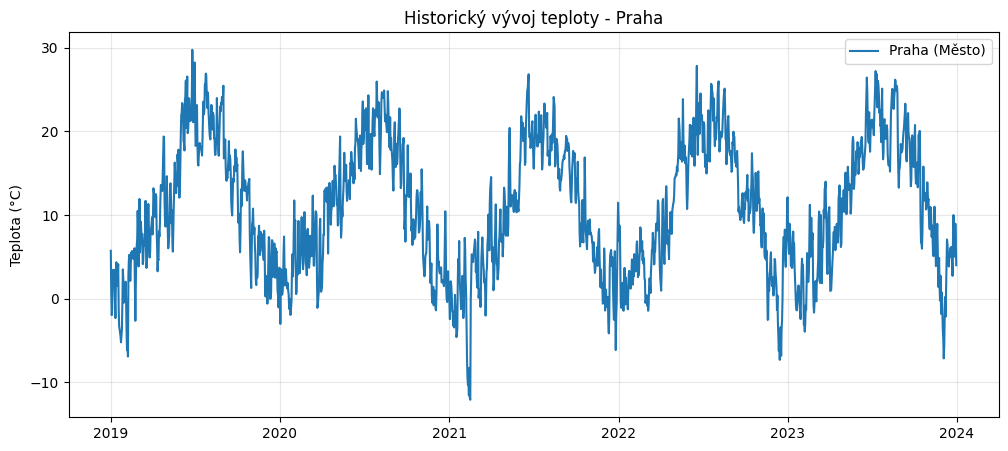

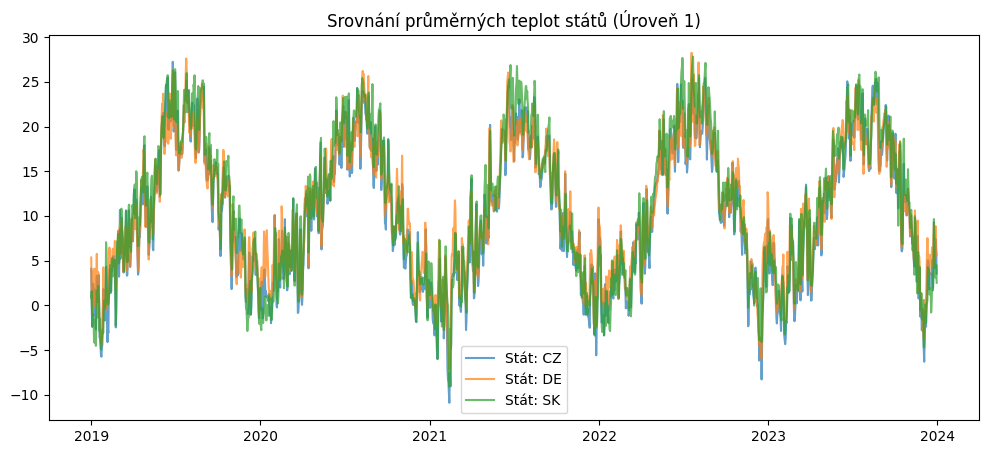

Souhrnné statistiky pro úroveň států:
          count       mean       std        min       25%        50%  \
country                                                                
AT       1826.0  11.141549  7.460070  -6.018833  4.877000  10.897834   
CZ       1826.0  10.211253  7.694444 -10.891583  3.806333   9.933416   
DE       1826.0  10.807753  7.084314  -7.150000  5.084375  10.415624   
PL       1826.0  10.360113  7.882208 -13.050000  3.925000  10.066667   
SK       1826.0  11.156743  8.163684  -9.087500  4.050000  11.125000   

               75%        max  
country                        
AT       17.560333  26.889502  
CZ       16.796958  27.233416  
DE       17.035937  28.243752  
PL       17.041666  27.600000  
SK       18.337500  27.812500  


In [7]:
import matplotlib.pyplot as plt

# Načtení dat pro vizualizaci
city_df = pd.read_csv('data/weather_city.csv', parse_dates=['date'])
country_df = pd.read_csv('data/weather_country.csv', parse_dates=['date'])

# Vizualizace trendu na úrovni města (Praha)
plt.figure(figsize=(12, 5))
plt.plot(city_df[city_df['city'] == 'Praha']['date'],
         city_df[city_df['city'] == 'Praha']['temp_mean'], label='Praha (Město)')
plt.title('Historický vývoj teploty - Praha')
plt.ylabel('Teplota (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Porovnání států
plt.figure(figsize=(12, 5))
for country in ['CZ', 'DE', 'SK']:
    subset = country_df[country_df['country'] == country]
    plt.plot(subset['date'], subset['temp_mean'], label=f'Stát: {country}', alpha=0.7)
plt.title('Srovnání průměrných teplot států (Úroveň 1)')
plt.legend()
plt.show()

# Souhrnné statistiky
print("Souhrnné statistiky pro úroveň států:")
print(country_df.groupby('country')['temp_mean'].describe())